# Basics


Computer simulaties zijn een belangrijk onderdeel bij natuurkundig onderzoek: wat we niet in het lab kunnen doen, of waar we niet goed aan kunnen meten, kunnen we alsnog bestuderen dankzij simulaties. In deze module leggen we de basis voor natuurkundige computer simulaties. Een aantal dingen kun je wellicht al, dan kun je deze overslaan.

De basis van een goede computer simulatie ligt, net als bij het oplossen van een natuurkundig probleem in een gedegen systematische aanpak. Deze begint vaak met:
1. Het maken van een tekening van de situatie
2. Het noteren van de werkformules
3. Het aangeven van richtingen en noteren van variabelen. 

```{exercise}
Als startopdracht modelleren we een massa-veer systeem. Doorloop de bovenstaande drie stappen. Maak een foto van je tekening en voeg deze toe.
```

<!-- Jouw antwoorden -->



Om een simulatie te maken, splitsen we het volledige proces op in kleine stappen met een vaste (tijd)interval, zoals in onderstaande figuur. Elk stapje krijgt een nummer, van 0 tot N. We gebruiken de letter i om naar een specifieke stap te verwijzen.

De gegevens in stap i worden gebruikt om de waarden in stap i+1 te berekenen, bijvoorbeeld:
$$x_{i+1} = x_i + v_i\cdot\Delta t$$

```{figure} ../figures/interval.jpg
:width: 50%

Het gehele proces wordt opgebroken in kleine stukken: tijdsdiscretisatie.
```

Wellicht heb je bovenstaande al eens gezien met het programma Coach. Anders dan bij Coach moeten we expliciet de waarden opslaan in een array. Omdat het steeds aanmaken van een nieuwe cel in een array veel rekentijd kost, is het handiger om eerst arrays te maken met waarde 0.

We nemen als voorbeeld twee fietsers, waarbij de fietser 1 een eenparige beweging uitvoert en fietser 2 een eenparig versnelde beweging:

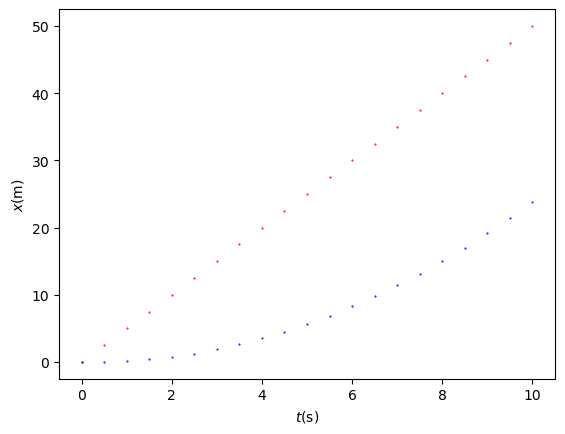

23.75


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Beginwaarden
dt = 0.25                #s
t_e = 10                 #s
N = int(t_e/dt)+1
t = np.arange(0,t_e+dt,dt)

# fietser 1
x_1 = np.zeros(N)          #m     maakt array van lengte N met alleen maar waarde 0.
v_1 = 5                  #m/s

# fietser 2
x_2 = np.zeros(N)          #m     
v_2 = np.zeros(N)          #m/s     
a_2 = .5                   #m/s^2     

# Uitvoeren van de simulatie
for i in range(0,N-1):
    x_1[i+1] = x_1[i] + v_1*dt
    
    x_2[i+1] = x_2[i] + v_2[i]*dt
    v_2[i+1] = v_2[i] + a_2*dt

# Plotten van de gegevens.    
plt.figure()

plt.xlabel('$t$(s)')
plt.ylabel('$x$(m)')

plt.plot(t,x_1,'r.', markersize=1, label='fietser 1')
plt.plot(t,x_2,'b.', markersize=1, label='fietser 2')

plt.show()


Wat op zou kunnen vallen is dat de snelheid in een cel constant gehouden wordt ($x_i = v_i\cdot\Delta t$), terwijl de snelheid tijdens het tijdsinterval $\Delta t$ toeneemt. De oplossing is dus een benadering van de exacte oplossing, maar door deze methode (Euler explicit forward), moeten we wel voorzichtig zijn met de grootte van het tijdsinterval.

```{exercise}
Maak het tijdsinterval dt groter en vergelijk de afgelegde weg in de tien seconde. Wat gebeurt er met de afgelegde weg als we dt groter maken? Is dat logisch vanuit gezien de natuurkunde? En gezien de methode van discretisatie? Leg uit.
```

<!-- Jouw antwoorden -->


```{exercise}
We gaan terug naar het massa-veer systeem. Hieronder staan reeds enkele gegevens van dat massa-veer systeem. Maak de simulatie en plot de uitkomst (d.w.z de uitwijking als functie van de tijd. Leg uit waarom de simulatie er niet goed uitziet.

```


In [31]:
k = 10        #N/m
g = 9.81      #m/s^2
m = .1        #kg
dt = 0.01     #s
t_e = 3       #s
N = int(t_e/dt)+1

u = np.zeros(N)
v = np.zeros(N)
u[0] = 5E-2   #m


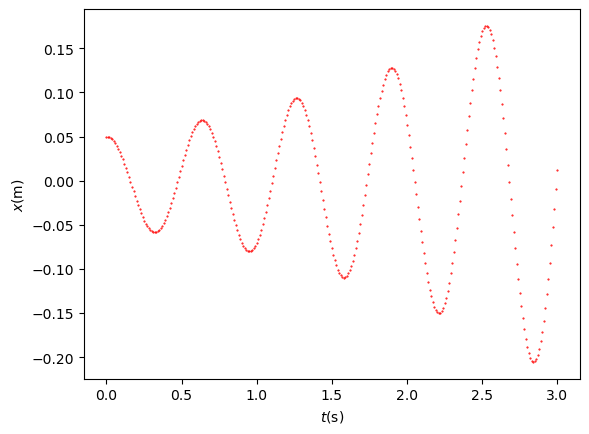

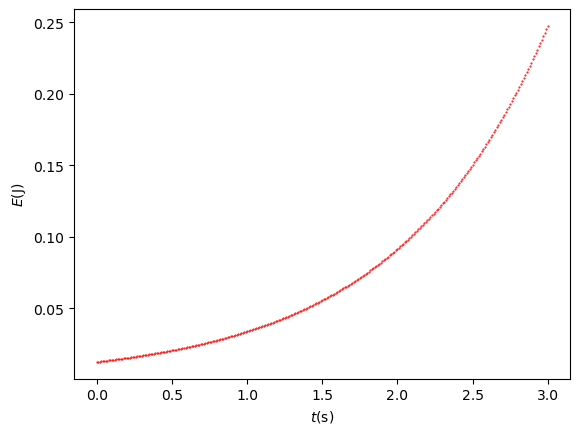

In [41]:
### BEGIN_SOLUTION
k = 10        #N/m
g = 9.81      #m/s^2
m = .1        #kg
dt = 0.01     #s
t_e = 3       #s
N = int(t_e/dt)+1
t = np.arange(0,t_e+dt,dt)

u = np.zeros(N)
v = np.zeros(N)
u[0] = 5E-2   #m

# Uitvoeren van de simulatie
for i in range(0,N-1):
    u[i+1] = u[i] + v[i]*dt
    v[i+1] = v[i] - k/m*u[i]*dt

# Plotten van de gegevens.    
plt.figure()

plt.xlabel('$t$(s)')
plt.ylabel('$x$(m)')

plt.plot(t,u,'r.', markersize=1, label='fietser 1')

plt.show()



plt.figure()

plt.xlabel('$t$(s)')
plt.ylabel('$E$(J)')

plt.plot(t,.5*m*v**2+1/2*k*u**2,'r.', markersize=1)

plt.show()
### END_SOLUTION

We zouden de simulatie iets beter kunnen maken door in de tweede stap in het proces de informatie van de nieuwe positie te gebruiken: $v_{i+1}=v_i - \frac{k}{m}\frac{x_i+x_{i+1}}{2}\Delta t$ 

```{exercise}
Pas dit toe in je code en voeg in beide code cellen de totale energie ($E_{kin}+E_z$) toe. Wat is een goede maat voor stabiliteit?
```


Er zijn betere (d.w.z. stabielere) oplossingen, zoals de Runge-Kutta 4 methode. Die werken we (mathematisch) hier niet uit. Zie je dat je simulatie instabiel is, dan kun je m.b.v. bijvoorbeeld co-pilot een betere simulatie krijgen.


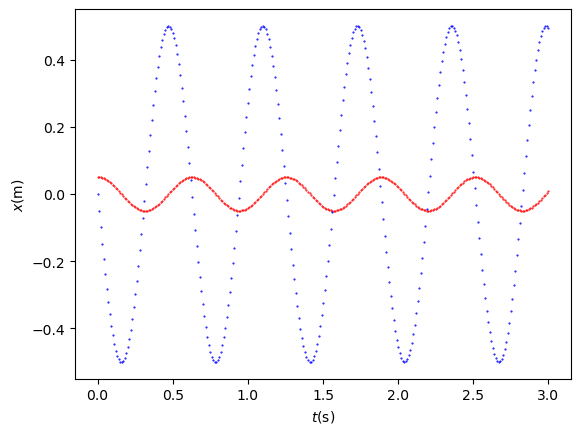

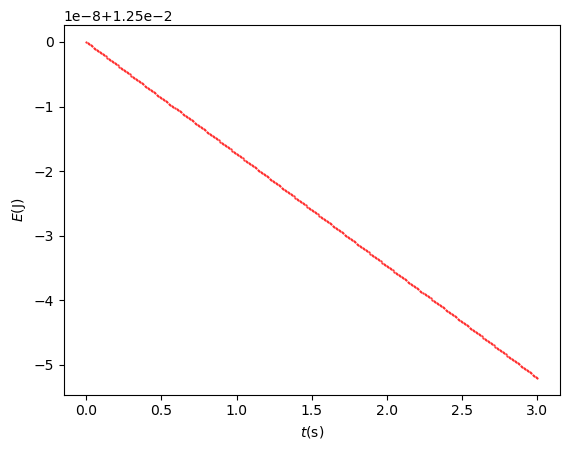

In [42]:
k = 10        #N/m
g = 9.81      #m/s^2
m = .1        #kg
dt = 0.01     #s
t_e = 3       #s
N = int(t_e/dt)+1
t = np.arange(0,t_e+dt,dt)

u = np.zeros(N)
v = np.zeros(N)
u[0] = 5E-2   #m

# Uitvoeren van de simulatie via RK4
for i in range(0, N-1):
    # u' = v
    # v' = -k/m * u

    # k1
    ku1 = v[i]
    kv1 = -k/m * u[i]

    # k2
    ku2 = v[i] + 0.5 * dt * kv1
    kv2 = -k/m * (u[i] + 0.5 * dt * ku1)

    # k3
    ku3 = v[i] + 0.5 * dt * kv2
    kv3 = -k/m * (u[i] + 0.5 * dt * ku2)

    # k4
    ku4 = v[i] + dt * kv3
    kv4 = -k/m * (u[i] + dt * ku3)

    # volgende stap
    u[i+1] = u[i] + dt/6 * (ku1 + 2*ku2 + 2*ku3 + ku4)
    v[i+1] = v[i] + dt/6 * (kv1 + 2*kv2 + 2*kv3 + kv4)

# Plotten van de gegevens.    
plt.figure()

plt.xlabel('$t$(s)')
plt.ylabel('$x$(m)')

plt.plot(t,u,'r.', markersize=1)
plt.plot(t,v,'b.', markersize=1)
plt.show()



plt.figure()

plt.xlabel('$t$(s)')
plt.ylabel('$E$(J)')

plt.plot(t,.5*m*v**2+1/2*k*u**2,'r.', markersize=1)

plt.show()